# Spam Email Classification — Model Evaluation

## Objective

This notebook evaluates the spam email classification models developed
during Week 2.

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The following models are compared:

1. Naive Bayes — Baseline
2. Logistic Regression — Baseline
3. Naive Bayes — Tuned
4. Logistic Regression — Tuned

The evaluation results were generated by `src/train.py`.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import Image, display

In [14]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    WEEK2_DIR = CURRENT_DIR.parent

elif CURRENT_DIR.name == "week-2":
    WEEK2_DIR = CURRENT_DIR

elif (CURRENT_DIR / "week-2").exists():
    WEEK2_DIR = CURRENT_DIR / "week-2"

else:
    raise FileNotFoundError(
        "Could not locate the week-2 folder."
    )

RESULTS_DIR = WEEK2_DIR / "results"

print("Current directory :", CURRENT_DIR)
print("Week 2 directory  :", WEEK2_DIR)
print("Results directory :", RESULTS_DIR)
print("Results exists    :", RESULTS_DIR.exists())

Current directory : d:\Arch_Tech_Internship\week-2\notebooks
Week 2 directory  : d:\Arch_Tech_Internship\week-2
Results directory : d:\Arch_Tech_Internship\week-2\results
Results exists    : True


In [15]:
print("Available result files:\n")

for file in sorted(RESULTS_DIR.iterdir()):
    print(file.name)

Available result files:

logistic_regression_baseline_confusion_matrix.png
logistic_regression_final_confusion_matrix.png
logistic_regression_tuned_confusion_matrix.png
model_comparison.csv
naive_bayes_baseline_confusion_matrix.png
naive_bayes_tuned_confusion_matrix.png


In [16]:
COMPARISON_FILE = RESULTS_DIR / "model_comparison.csv"

results = pd.read_csv(COMPARISON_FILE)

print("Model comparison loaded successfully.")

results

Model comparison loaded successfully.


,Model,Stage,Accuracy,Precision,Recall,F1-score,CV Best Accuracy,Best Parameters
0,Naive Bayes,Baseline,0.973178,0.984569,0.964940,0.974656,NaN,NaN
1,Logistic Regression,Baseline,0.981935,0.976602,0.989918,0.983215,NaN,NaN
2,Naive Bayes,Tuned,0.983221,0.993232,0.975252,0.984160,0.982119,"{'classifier__alpha': 0.1, 'tfidf__min_df': 2,..."
3,Logistic Regression,Tuned,0.986467,0.983407,0.991407,0.987391,0.985089,"{'classifier__C': 2.0, 'classifier__class_weig..."


In [17]:
results_sorted = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_sorted

,Model,Stage,Accuracy,Precision,Recall,F1-score,CV Best Accuracy,Best Parameters
0,Logistic Regression,Tuned,0.986467,0.983407,0.991407,0.987391,0.985089,"{'classifier__C': 2.0, 'classifier__class_weig..."
1,Naive Bayes,Tuned,0.983221,0.993232,0.975252,0.984160,0.982119,"{'classifier__alpha': 0.1, 'tfidf__min_df': 2,..."
2,Logistic Regression,Baseline,0.981935,0.976602,0.989918,0.983215,NaN,NaN
3,Naive Bayes,Baseline,0.973178,0.984569,0.964940,0.974656,NaN,NaN


In [18]:
display_results = results.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

for column in metric_columns:
    display_results[column] = (
        display_results[column] * 100
    ).round(2)

display_results


,Model,Stage,Accuracy,Precision,Recall,F1-score,CV Best Accuracy,Best Parameters
0,Naive Bayes,Baseline,97.32,98.46,96.49,97.47,NaN,NaN
1,Logistic Regression,Baseline,98.19,97.66,98.99,98.32,NaN,NaN
2,Naive Bayes,Tuned,98.32,99.32,97.53,98.42,0.982119,"{'classifier__alpha': 0.1, 'tfidf__min_df': 2,..."
3,Logistic Regression,Tuned,98.65,98.34,99.14,98.74,0.985089,"{'classifier__C': 2.0, 'classifier__class_weig..."


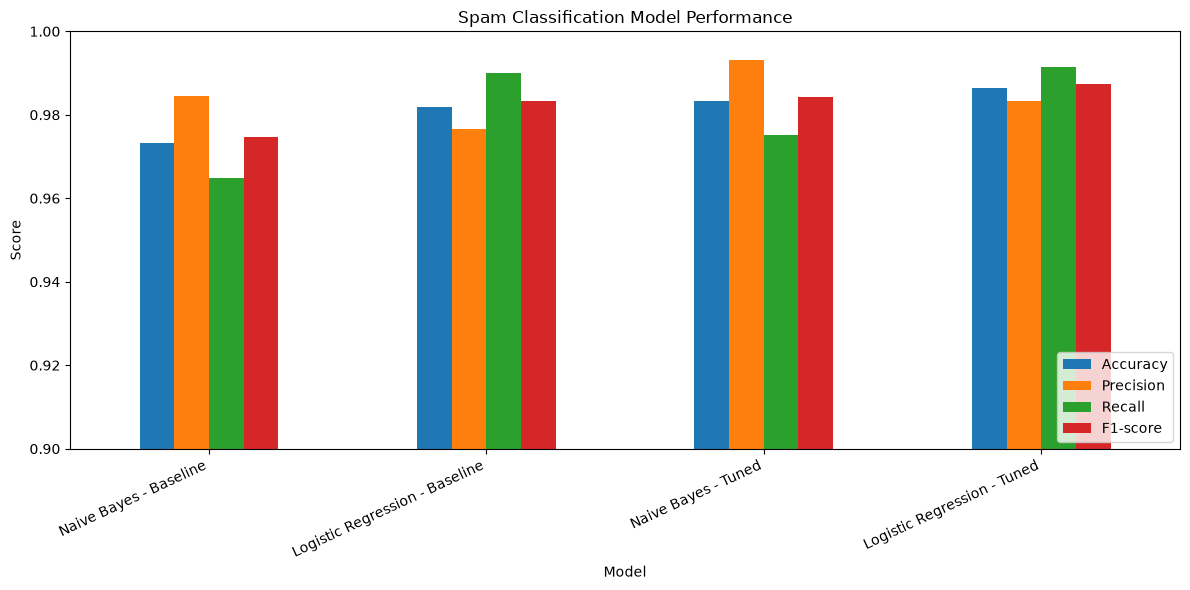

In [19]:
plot_results = results.copy()

plot_results["Model Description"] = (
    plot_results["Model"]
    + " - "
    + plot_results["Stage"]
)

ax = plot_results.plot(
    x="Model Description",
    y=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Spam Classification Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.90, 1.00)
plt.xticks(rotation=25, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

## Confusion Matrices

The following confusion matrices were generated during model training
and are loaded directly from the `results` directory.

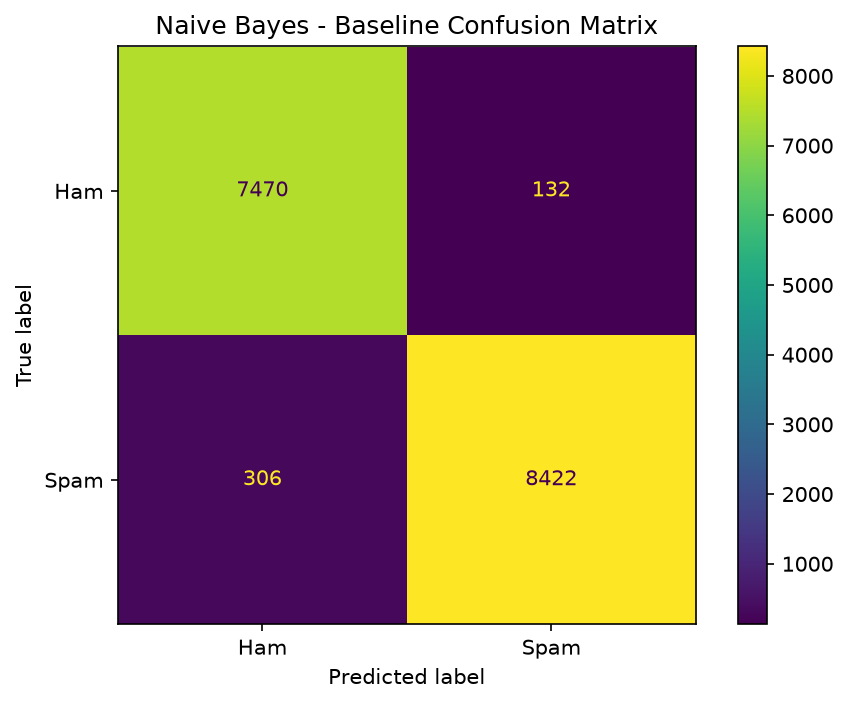

In [20]:
display(
    Image(
        filename=str(
            RESULTS_DIR /
            "naive_bayes_baseline_confusion_matrix.png"
        )
    )
)

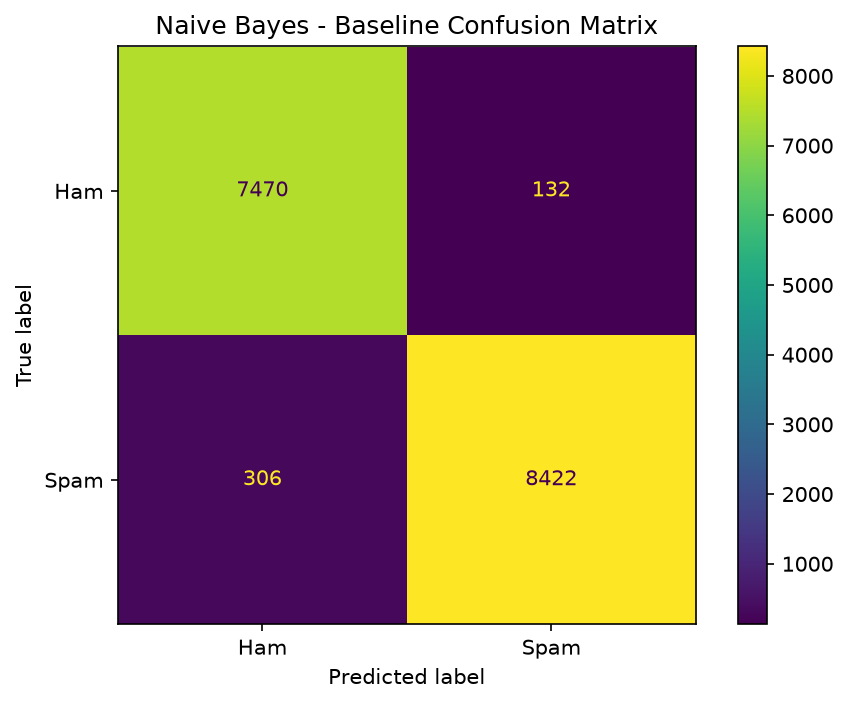

In [21]:
display(
    Image(
        filename=str(
            RESULTS_DIR /
            "naive_bayes_baseline_confusion_matrix.png"
        )
    )
)

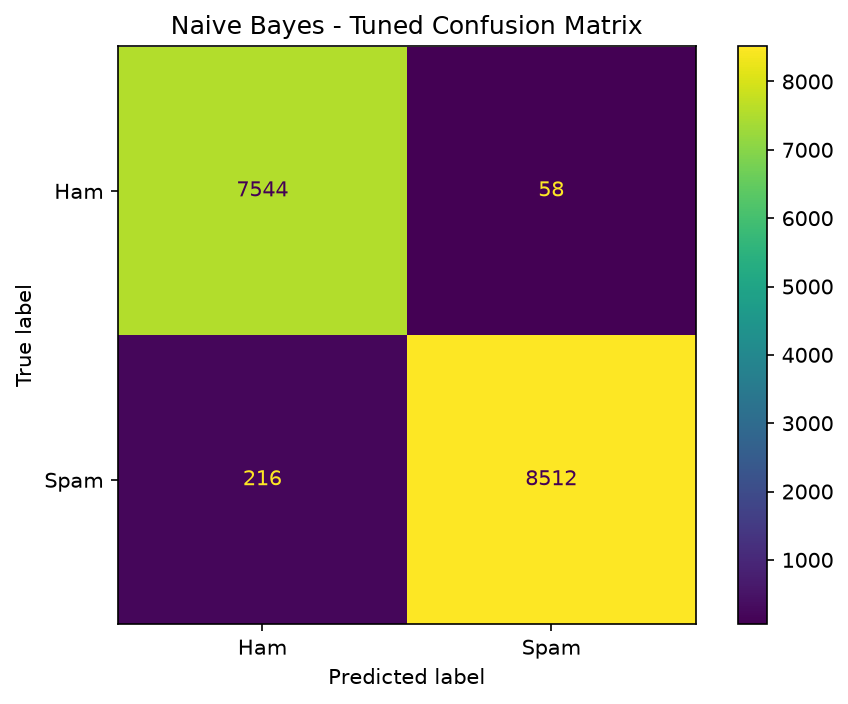

In [22]:
display(
    Image(
        filename=str(
            RESULTS_DIR /
            "naive_bayes_tuned_confusion_matrix.png"
        )
    )
)

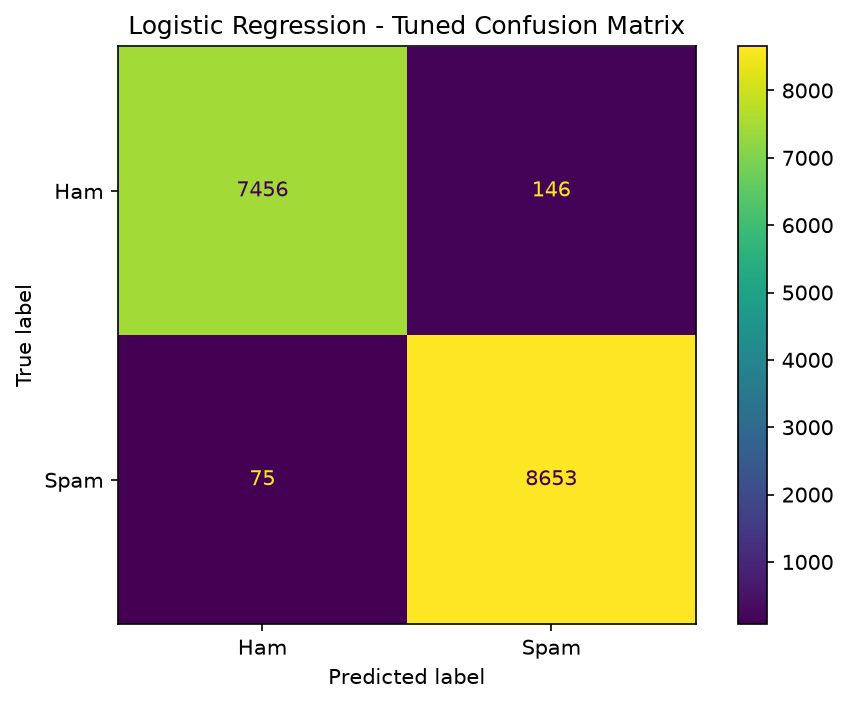

In [23]:
display(
    Image(
        filename=str(
            RESULTS_DIR /
            "logistic_regression_tuned_confusion_matrix.png"
        )
    )
)

In [24]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(
    f"Model     : {best_model['Model']}"
)
print(
    f"Stage     : {best_model['Stage']}"
)
print(
    f"Accuracy  : {best_model['Accuracy']:.4f}"
)
print(
    f"Precision : {best_model['Precision']:.4f}"
)
print(
    f"Recall    : {best_model['Recall']:.4f}"
)
print(
    f"F1-score  : {best_model['F1-score']:.4f}"
)

BEST MODEL
Model     : Logistic Regression
Stage     : Tuned
Accuracy  : 0.9865
Precision : 0.9834
Recall    : 0.9914
F1-score  : 0.9874


## Evaluation Conclusion

Both Naive Bayes and Logistic Regression achieved strong performance
for spam email classification.

Hyperparameter tuning improved the performance of both models.

The **Tuned Logistic Regression** model achieved the best overall
performance and was therefore selected as the final classifier.

### Final Performance

| Metric | Score |
|---|---:|
| Accuracy | 98.65% |
| Precision | 98.34% |
| Recall | 99.14% |
| F1-score | 98.74% |

The trained final model is stored in:

`models/spam_classifier.joblib`